<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Unit_Circles_and_Nth_Root_of_Unity_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)


## Plotted Unit Circles and Nth Root of Unity

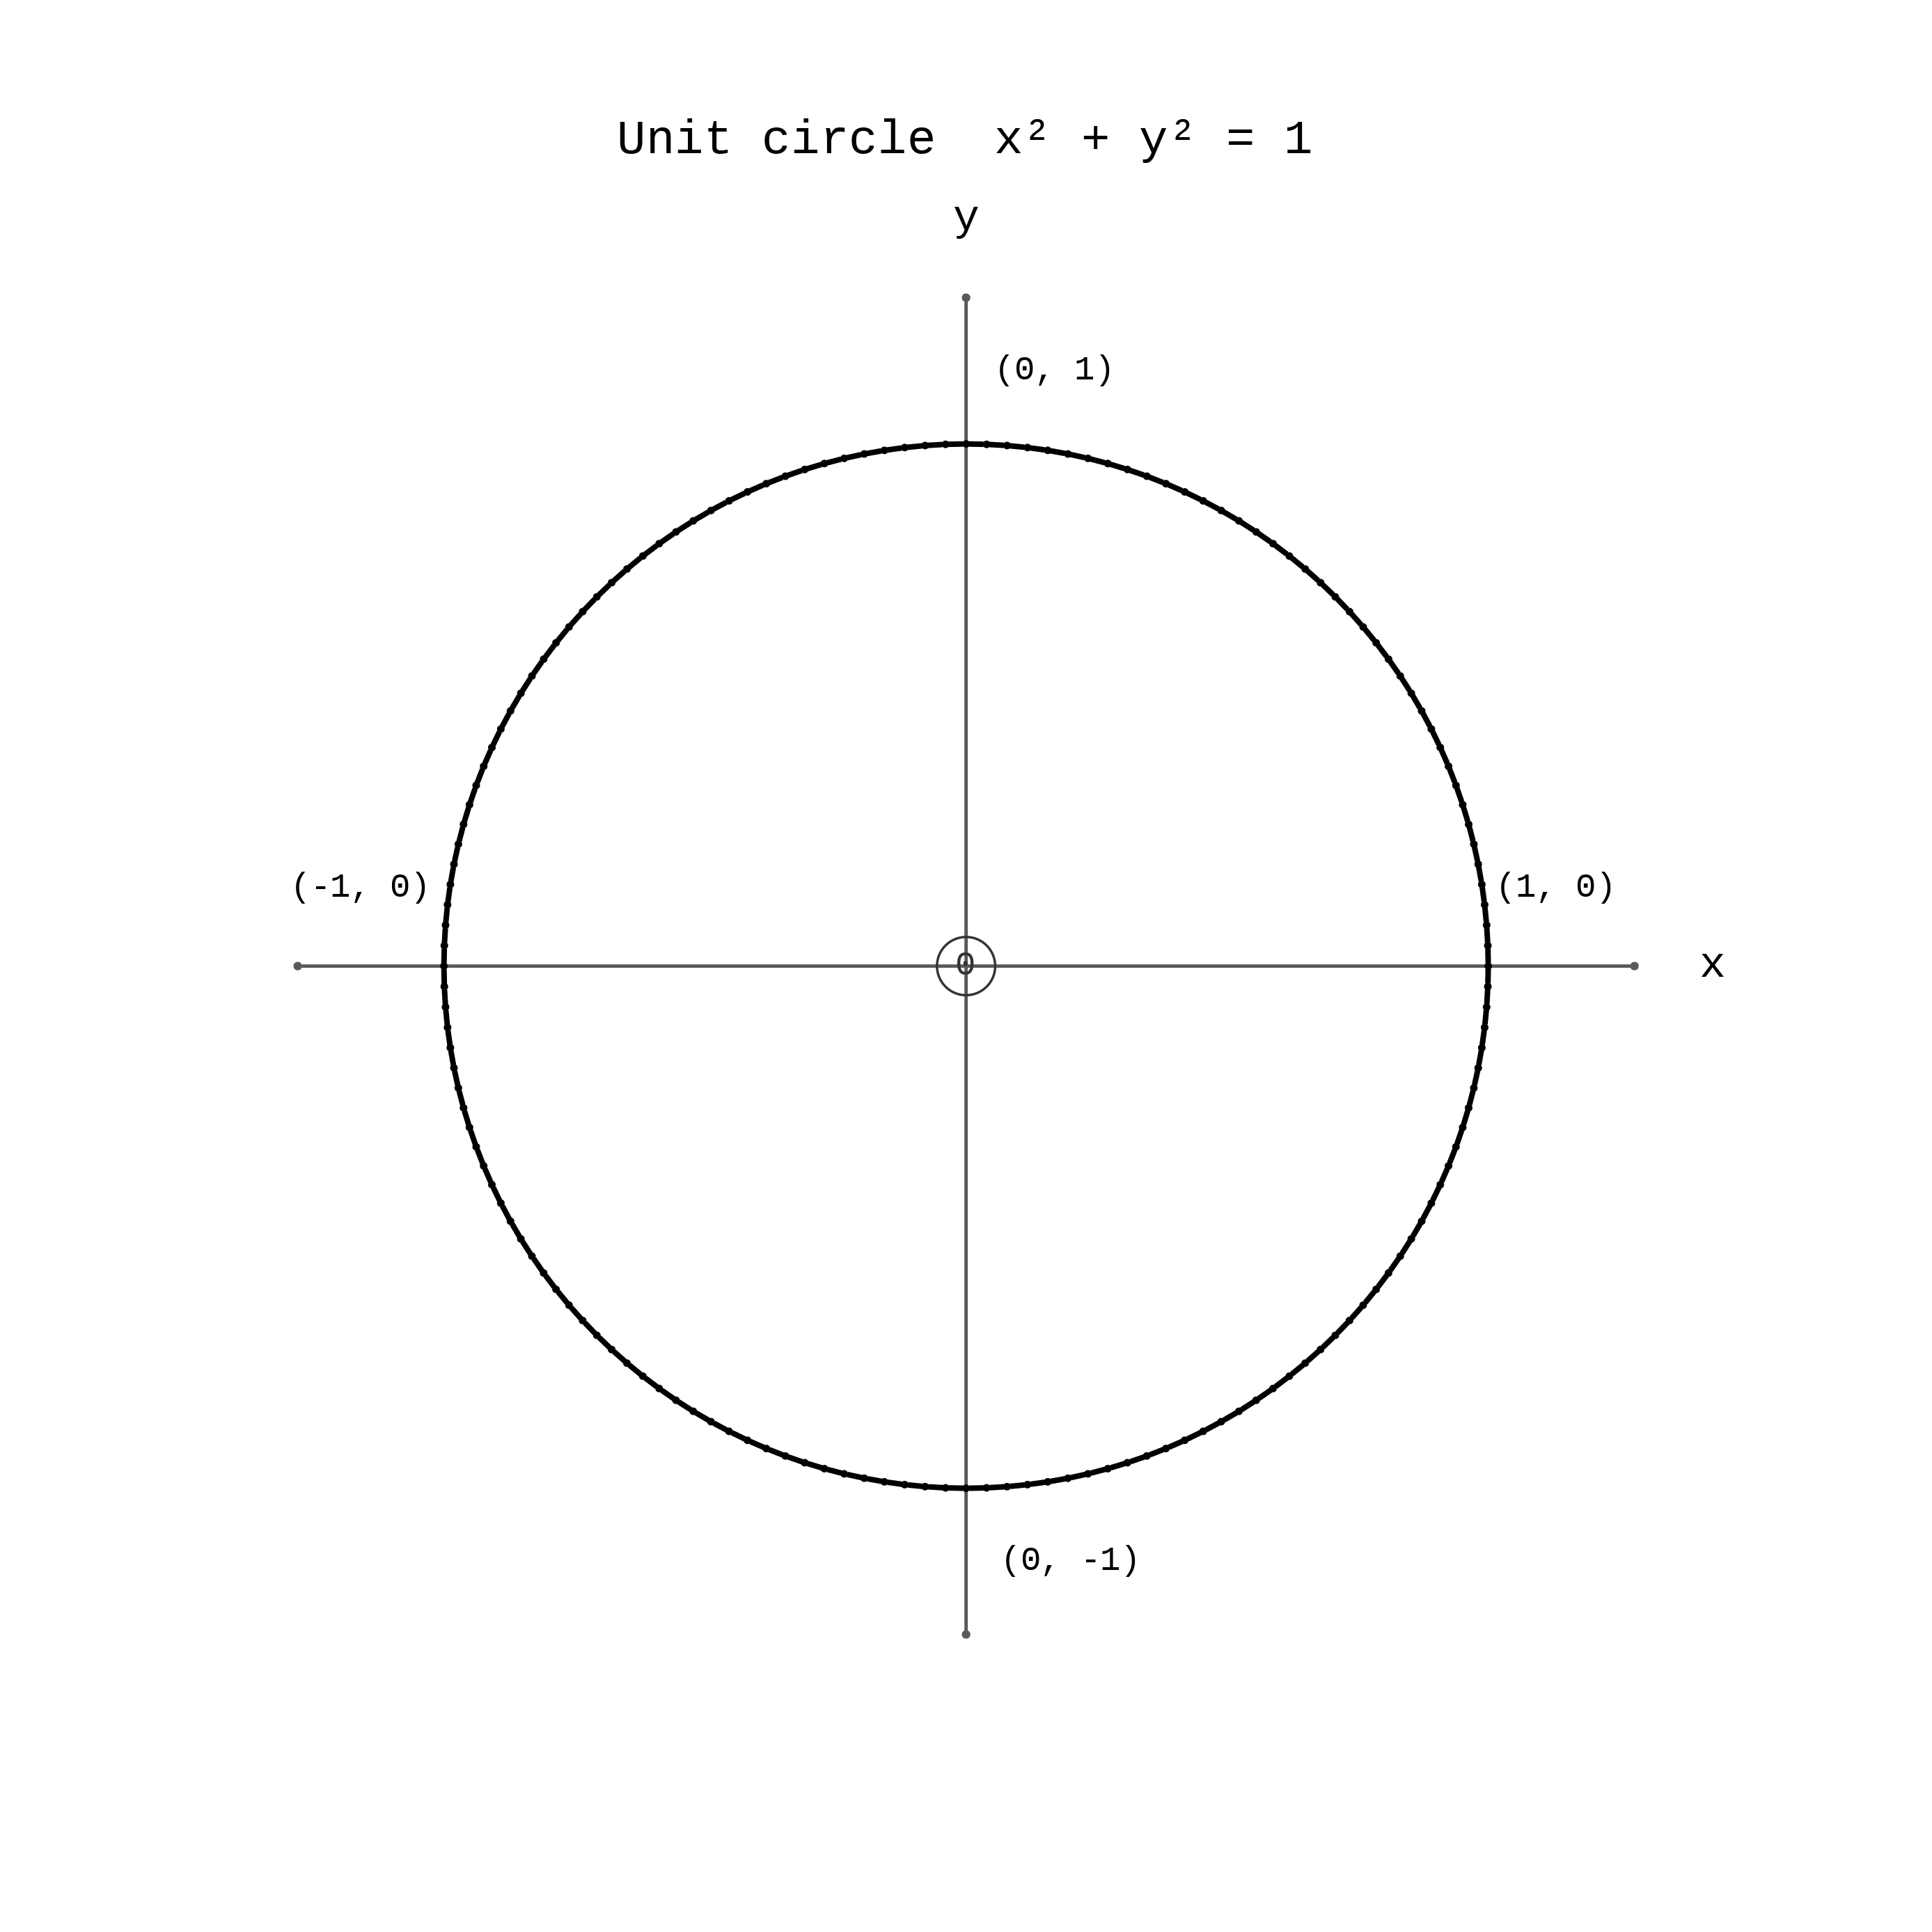

In [3]:
"""Render a geometrically accurate Graphviz unit circle strictly in-memory."""

!pip install --quiet graphviz ipython

import math

import graphviz
from IPython.display import Image, display

# =============================================================================
# Control knobs
# =============================================================================
NUM_CIRCLE_POINTS = 160
RADIUS = 1.0
SCALE = 3.0
PNG_DPI = "250"  # Dots Per Inch

CIRCLE_POINT_SIZE = "0.030"
CIRCLE_LINE_WIDTH = "2.3"
AXIS_LINE_WIDTH = "1.4"
FONT_FAMILY = "Tahoma"

SHOW_CIRCLE_POINTS = True
SHOW_CARDINAL_POINTS = True
SHOW_AXIS_LABELS = True
SHOW_TITLE = True


def add_point_node(
    graph: graphviz.Graph,
    name: str,
    x_pos: float,
    y_pos: float,
    size: str = CIRCLE_POINT_SIZE,
    color: str = "black",
) -> None:
    """Add a small fixed-position point node to the graph."""
    graph.node(
        name,
        label="",
        shape="point",
        width=size,
        height=size,
        fixedsize="true",
        pos=f"{x_pos:.8f},{y_pos:.8f}!",
        pin="true",
        color=color,
    )


def add_text_node(
    graph: graphviz.Graph,
    name: str,
    label: str,
    x_pos: float,
    y_pos: float,
    fontsize: str = "14",
) -> None:
    """Add a fixed-position text label with size determined by its text."""
    graph.node(
        name,
        label=label,
        shape="plaintext",
        fixedsize="false",
        width="0",
        height="0",
        margin="0.02",
        pos=f"{x_pos:.8f},{y_pos:.8f}!",
        pin="true",
        fontsize=fontsize,
        fontname=FONT_FAMILY,
        color="black",
        fontcolor="black",
    )


# =============================================================================
# Build Graphviz diagram
# =============================================================================
dot = graphviz.Graph(
    name="unit_circle",
    engine="neato",
    graph_attr={
        "layout": "neato",
        "splines": "line",
        "overlap": "true",
        "outputorder": "edgesfirst",
        "bgcolor": "white",
        "dpi": PNG_DPI,
        "margin": "0.25",
        "pad": "0.20",
        "normalize": "false",
    },
    edge_attr={
        "fontname": FONT_FAMILY,
    },
)

# Invisible bounding points preserve the canvas extent.
bound = 1.70 * SCALE
for name, x_pos, y_pos in (
    ("bound_left", -bound, 0.0),
    ("bound_right", bound, 0.0),
    ("bound_bottom", 0.0, -bound),
    ("bound_top", 0.0, bound),
):
    add_point_node(dot, name, x_pos, y_pos, size="0.001", color="white")

# Axes.
axis_extent = 1.28 * SCALE
add_point_node(dot, "x_minus", -axis_extent, 0.0, size="0.035", color="gray35")
add_point_node(dot, "x_plus", axis_extent, 0.0, size="0.035", color="gray35")
add_point_node(dot, "y_minus", 0.0, -axis_extent, size="0.035", color="gray35")
add_point_node(dot, "y_plus", 0.0, axis_extent, size="0.035", color="gray35")

dot.edge("x_minus", "x_plus", color="gray35", penwidth=AXIS_LINE_WIDTH)
dot.edge("y_minus", "y_plus", color="gray35", penwidth=AXIS_LINE_WIDTH)

# Circle perimeter.
circle_nodes = []
for idx in range(NUM_CIRCLE_POINTS):
    theta = 2.0 * math.pi * idx / NUM_CIRCLE_POINTS
    x_pos = SCALE * RADIUS * math.cos(theta)
    y_pos = SCALE * RADIUS * math.sin(theta)
    node_name = f"c_{idx:03d}"
    circle_nodes.append(node_name)

    if SHOW_CIRCLE_POINTS:
        add_point_node(dot, node_name, x_pos, y_pos)
    else:
        add_point_node(dot, node_name, x_pos, y_pos, size="0.001")

for idx in range(NUM_CIRCLE_POINTS):
    dot.edge(
        circle_nodes[idx],
        circle_nodes[(idx + 1) % NUM_CIRCLE_POINTS],
        color="black",
        penwidth=CIRCLE_LINE_WIDTH,
    )

# Origin.
dot.node(
    "origin",
    label="0",
    shape="circle",
    fixedsize="false",
    width="0.18",
    height="0.18",
    margin="0.02",
    pos="0,0!",
    pin="true",
    color="gray20",
    fontcolor="gray20",
    fontname=FONT_FAMILY,
    fontsize="14",
)

# Cardinal point labels.
if SHOW_CARDINAL_POINTS:
    add_text_node(dot, "label_pos_x", "(1, 0)", 1.13 * SCALE, 0.15 * SCALE)
    add_text_node(dot, "label_neg_x", "(-1, 0)", -1.16 * SCALE, 0.15 * SCALE)
    add_text_node(dot, "label_pos_y", "(0, 1)", 0.17 * SCALE, 1.14 * SCALE)
    add_text_node(dot, "label_neg_y", "(0, -1)", 0.20 * SCALE, -1.14 * SCALE)

# Axis labels.
if SHOW_AXIS_LABELS:
    add_text_node(dot, "x_label", "x", 1.43 * SCALE, 0.0, fontsize="18")
    add_text_node(dot, "y_label", "y", 0.0, 1.43 * SCALE, fontsize="18")

# Title equation.
if SHOW_TITLE:
    add_text_node(
        dot,
        "equation",
        "Unit circle  x² + y² = 1",
        0.0,
        1.58 * SCALE,
        fontsize="20",
    )

# =============================================================================
# Render and display PNG in-memory
# =============================================================================
png_bytes = dot.pipe(format="png")
display(Image(data=png_bytes))

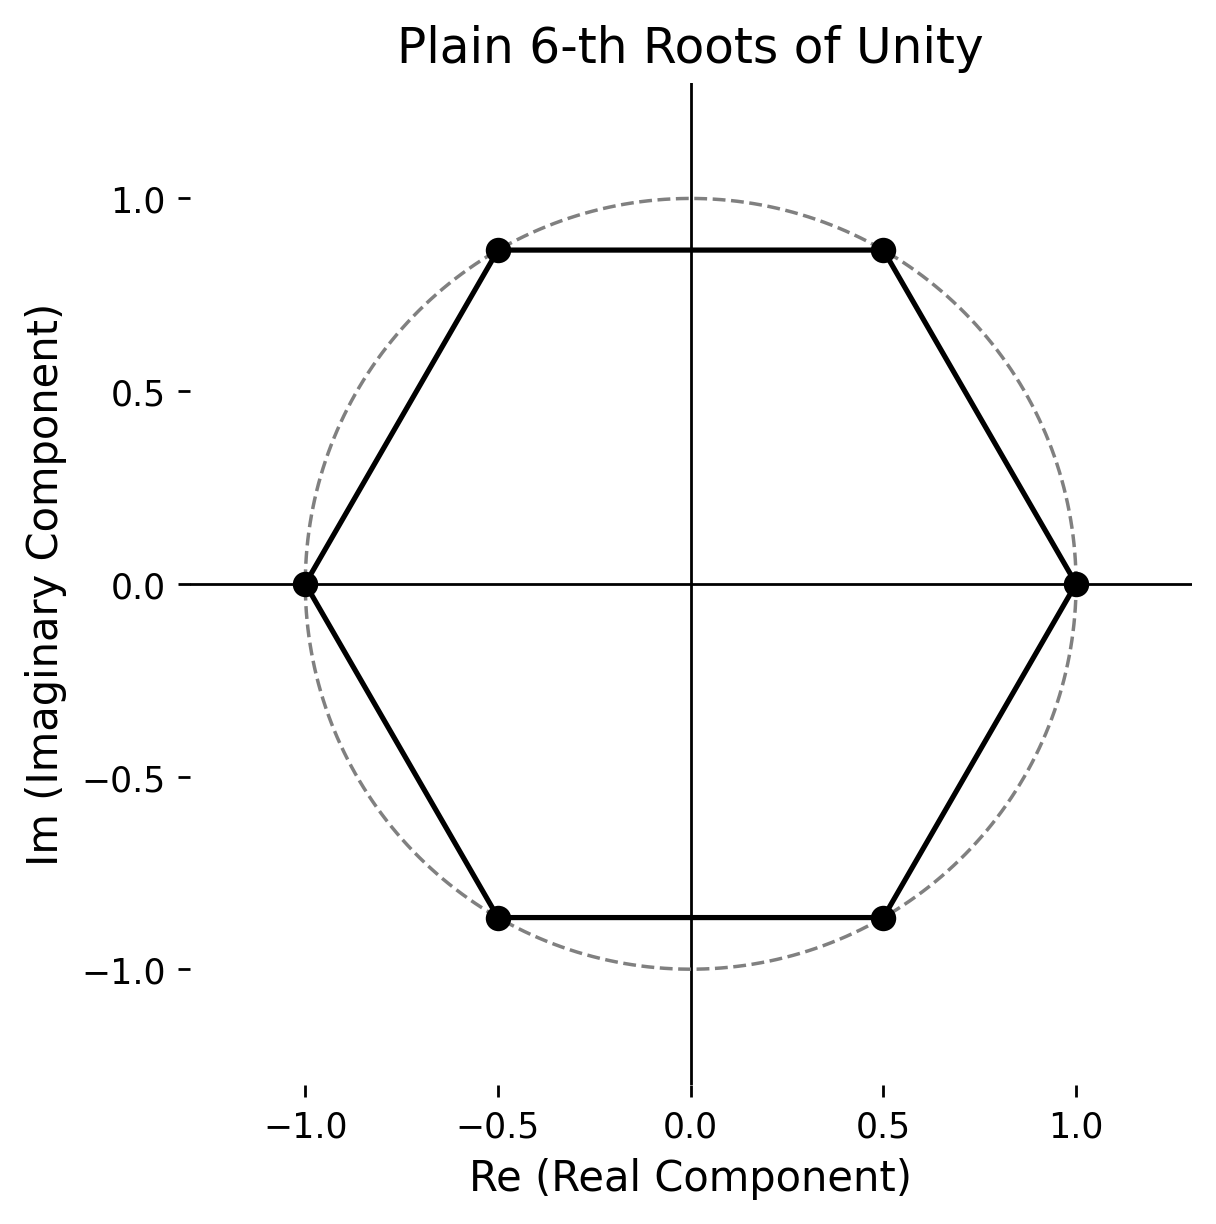

In [5]:
"""
Compute and plot the complex N-th roots of unity upon a standard unit circle.

This module utilizes the Matplotlib and NumPy libraries to analytically generate
the discrete spatial coordinates corresponding to the fundamental solutions of the
polynomial equation z^N = 1. The script employs a pure Cartesian coordinate mapping
approach to render the continuous mathematical perimeter alongside the exact geometric
root locations.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =============================================================================
# Control knobs
# =============================================================================
N_ROOTS = 6  # The fundamental integer defining the total number of complex roots.

PLOT_DPI = 250
FIGURE_SIZE_INCHES = (5.0, 5.0)

CIRCLE_LINE_COLOR = "gray"
CIRCLE_LINE_WIDTH = 1.0
CIRCLE_LINE_STYLE = "--"

ROOT_MARKER_COLOR = "black"
ROOT_MARKER_SIZE = 40
POLYGON_LINE_COLOR = "black"
POLYGON_LINE_WIDTH = 1.5

AXIS_LABEL_SIZE = 12
TITLE_FONT_SIZE = 14

# Enforce the strict typographic and resolution parameters globally.
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = PLOT_DPI

def render_roots_of_unity(n_val: int) -> None:
    """Calculate the complex roots and generate the corresponding geometric plot."""
    fig, ax = plt.subplots(figsize=FIGURE_SIZE_INCHES)

    # Generate the continuous unit circle perimeter parameters.
    theta_continuous = np.linspace(0, 2 * np.pi, 300)
    x_circle = np.cos(theta_continuous)
    y_circle = np.sin(theta_continuous)

    # Plot the foundational unit circle.
    ax.plot(
        x_circle,
        y_circle,
        color=CIRCLE_LINE_COLOR,
        linewidth=CIRCLE_LINE_WIDTH,
        linestyle=CIRCLE_LINE_STYLE,
        zorder=1
    )

    # Compute the exact complex roots utilizing standard trigonometric projection.
    indices = np.arange(n_val)
    angles = (2 * np.pi * indices) / n_val
    x_roots = np.cos(angles)
    y_roots = np.sin(angles)

    # Close the regular geometric polygon by appending the initial spatial coordinate.
    x_polygon = np.append(x_roots, x_roots[0])
    y_polygon = np.append(y_roots, y_roots[0])

    # Plot the interconnecting regular polygonal boundaries.
    ax.plot(
        x_polygon,
        y_polygon,
        color=POLYGON_LINE_COLOR,
        linewidth=POLYGON_LINE_WIDTH,
        zorder=2
    )

    # Scatter the discrete root nodes prominently upon the visual canvas.
    ax.scatter(
        x_roots,
        y_roots,
        color=ROOT_MARKER_COLOR,
        s=ROOT_MARKER_SIZE,
        zorder=3
    )

    # Configure the central coordinate axes for mathematical clarity.
    ax.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax.axvline(0, color="black", linewidth=0.8, zorder=0)

    # Apply formal labels and structural bounding limits.
    ax.set_aspect("equal")
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_xlabel("Re (Real Component)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Im (Imaginary Component)", fontsize=AXIS_LABEL_SIZE)
    ax.set_title(f"Plain {n_val}-th Roots of Unity", fontsize=TITLE_FONT_SIZE)

    # Eliminate the enclosing bounding box while retaining the cardinal axes.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

    # Render the compiled plot instantly within the active memory buffer.
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_roots_of_unity(N_ROOTS)

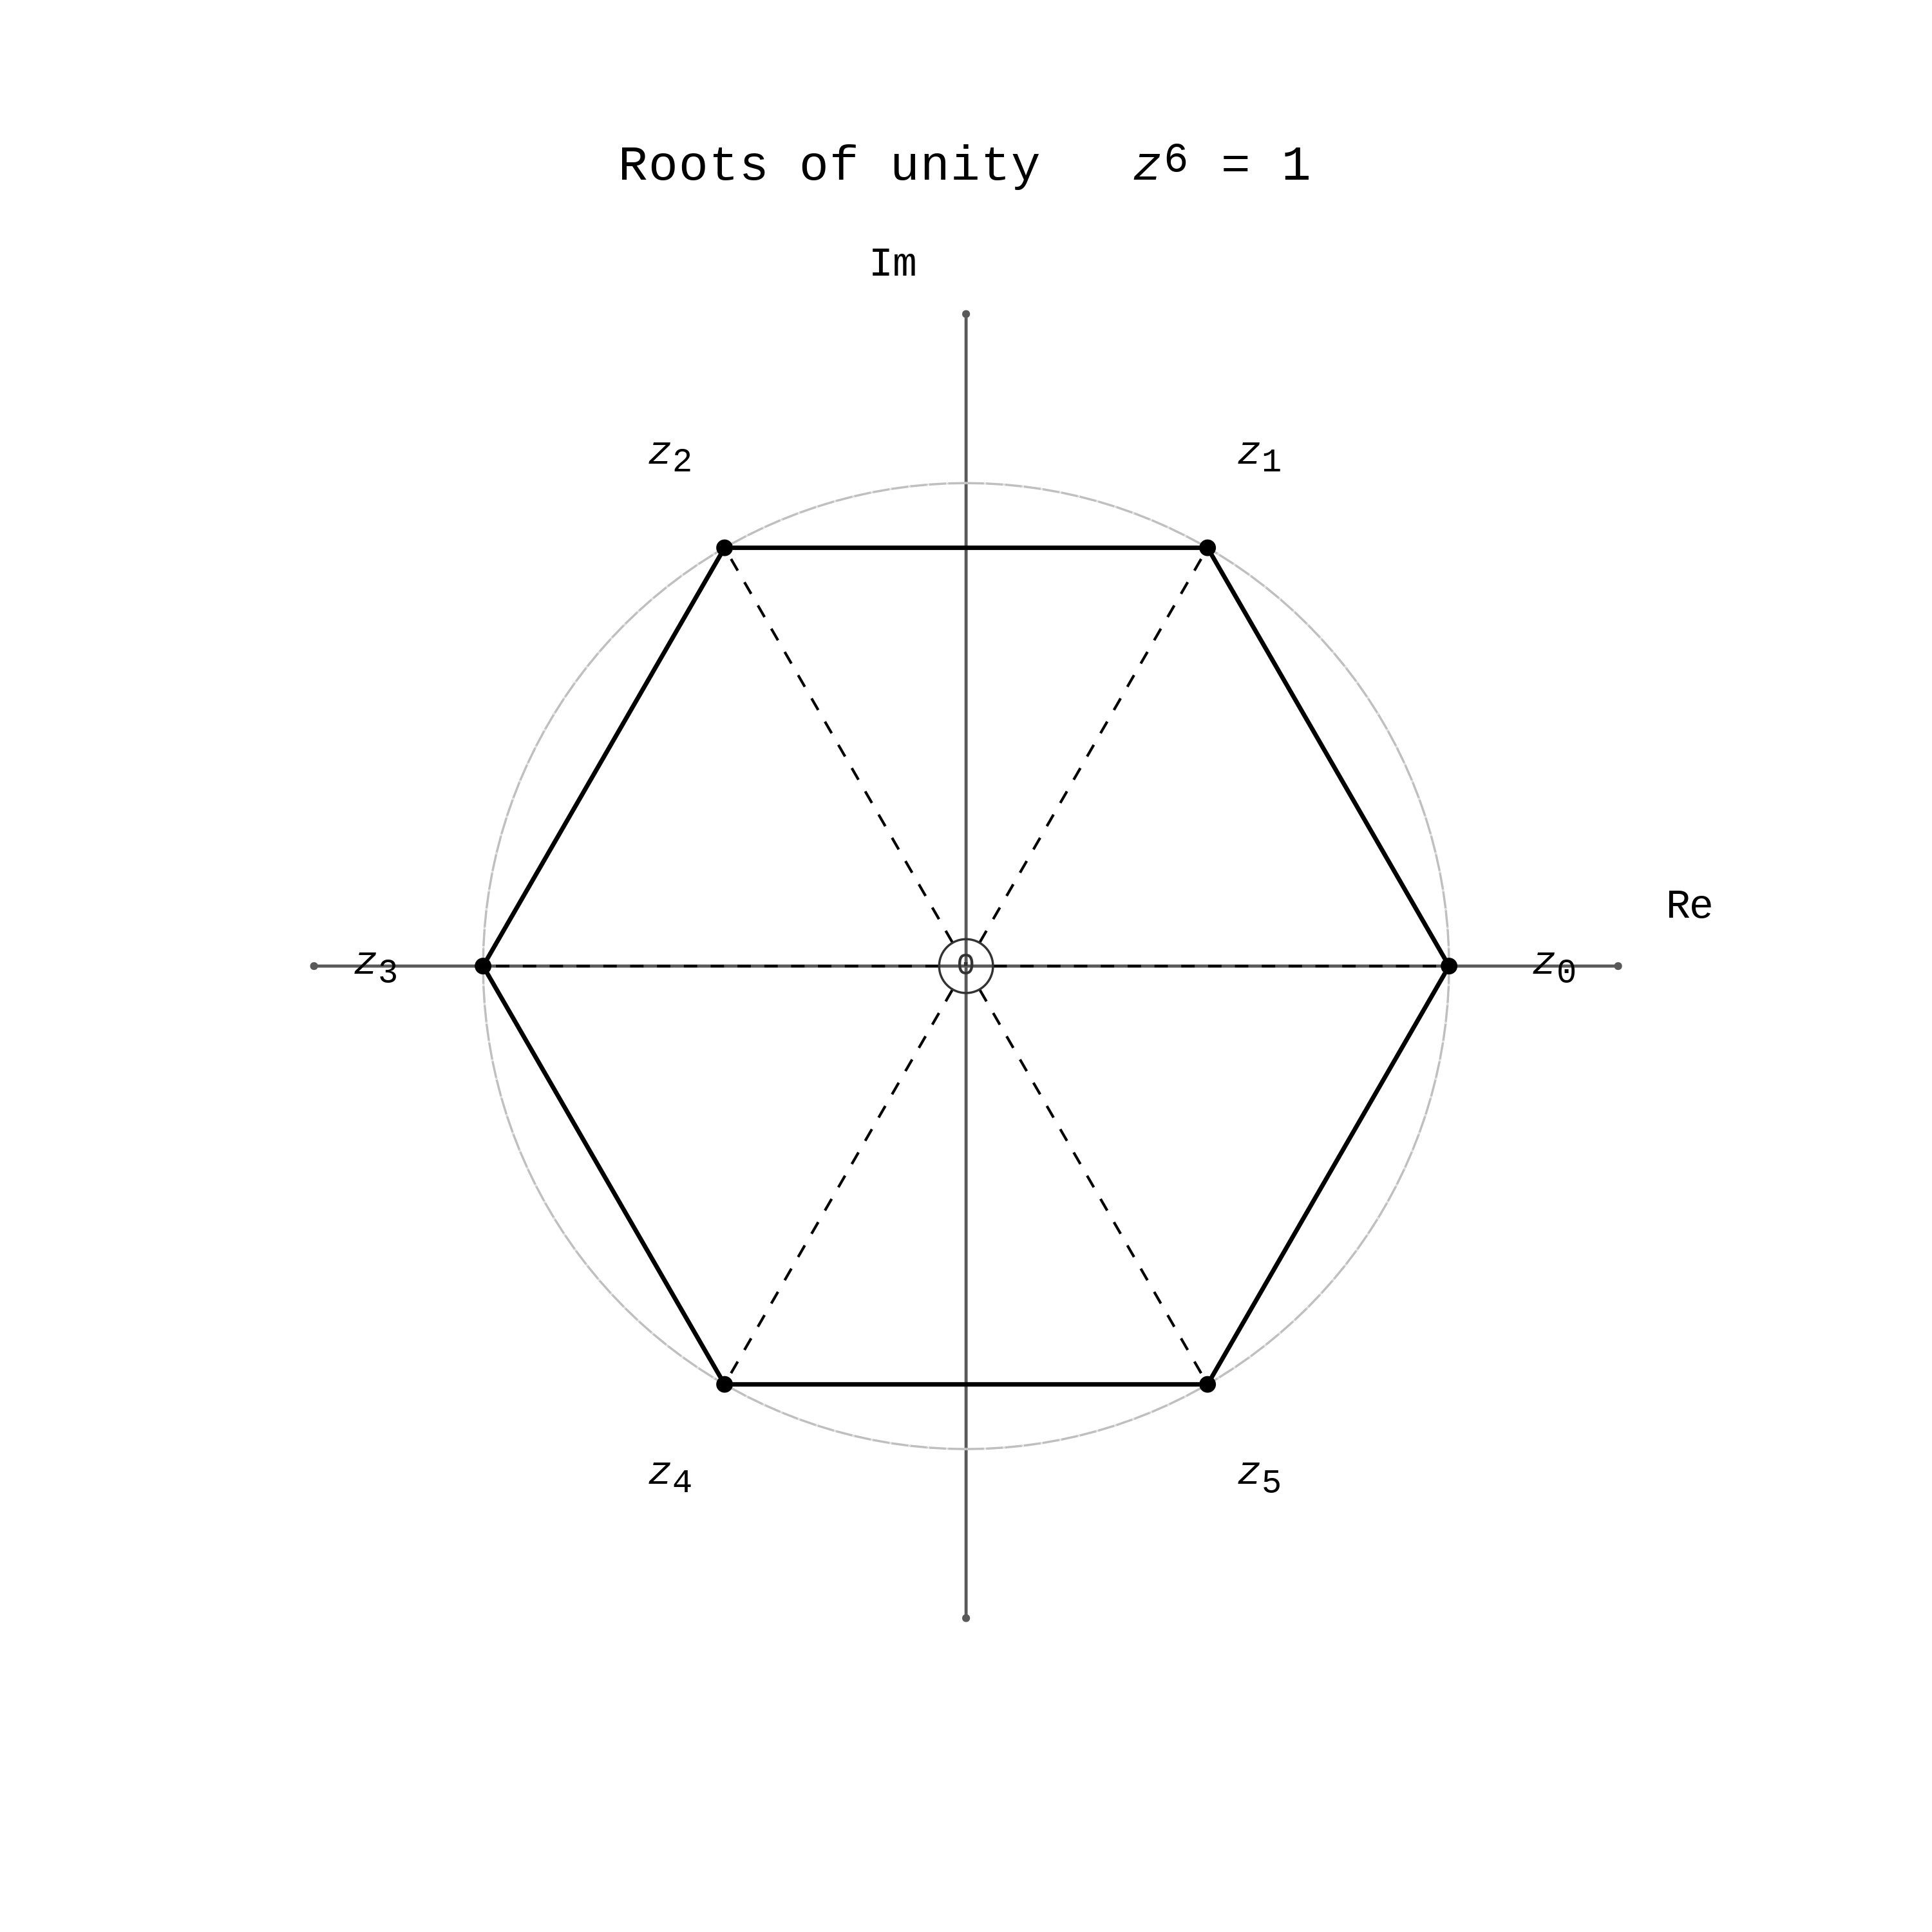

In [4]:
"""
Render a geometrically accurate Graphviz unit circle displaying the Nth roots of unity.
"""

import math

import graphviz
from IPython.display import Image, display

# =============================================================================
# Control knobs
# =============================================================================
N_ROOTS = 6  # Adjust this primary integer parameter to visualize any Nth root of unity.

NUM_CIRCLE_POINTS = 160
RADIUS = 1.0
SCALE = 3.0
PNG_DPI = "250"  # Dots Per Inch

CIRCLE_POINT_SIZE = "0.030"
CIRCLE_LINE_WIDTH = "1.0"
AXIS_LINE_WIDTH = "1.4"
FONT_FAMILY = "Tahoma"

ROOT_POINT_SIZE = "0.090"
ROOT_LINE_WIDTH = "2.0"
ROOT_COLOR = "black"

SHOW_CIRCLE_POINTS = False
SHOW_CARDINAL_POINTS = False
SHOW_AXIS_LABELS = True
SHOW_TITLE = True
SHOW_ROOT_POLYGON = True
SHOW_ROOT_RADII = True


def add_point_node(
    graph: graphviz.Graph,
    name: str,
    x_pos: float,
    y_pos: float,
    size: str = CIRCLE_POINT_SIZE,
    color: str = "black",
) -> None:
    """Add a small fixed position point node to the graph layout."""
    graph.node(
        name,
        label="",
        shape="point",
        width=size,
        height=size,
        fixedsize="true",
        pos=f"{x_pos:.8f},{y_pos:.8f}!",
        pin="true",
        color=color,
    )


def add_text_node(
    graph: graphviz.Graph,
    name: str,
    label: str,
    x_pos: float,
    y_pos: float,
    fontsize: str = "14",
) -> None:
    """Add a fixed position text label with spatial dimensions determined by its content."""
    graph.node(
        name,
        label=label,
        shape="plaintext",
        fixedsize="false",
        width="0",
        height="0",
        margin="0.02",
        pos=f"{x_pos:.8f},{y_pos:.8f}!",
        pin="true",
        fontsize=fontsize,
        fontname=FONT_FAMILY,
        color="black",
        fontcolor="black",
    )


def add_html_text_node(
    graph: graphviz.Graph,
    name: str,
    html_label: str,
    x_pos: float,
    y_pos: float,
    fontsize: str = "14",
) -> None:
    """Add a fixed position text label utilizing HyperText Markup Language formatting."""
    graph.node(
        name,
        label=f"<{html_label}>",
        shape="plaintext",
        fixedsize="false",
        width="0",
        height="0",
        margin="0.02",
        pos=f"{x_pos:.8f},{y_pos:.8f}!",
        pin="true",
        fontsize=fontsize,
        fontname=FONT_FAMILY,
        color="black",
        fontcolor="black",
    )


# =============================================================================
# Build Graphviz diagram
# =============================================================================
dot = graphviz.Graph(
    name="roots_of_unity",
    engine="neato",
    graph_attr={
        "layout": "neato",
        "splines": "line",
        "overlap": "true",
        "outputorder": "edgesfirst",
        "bgcolor": "white",
        "dpi": PNG_DPI,
        "margin": "0.25",
        "pad": "0.20",
        "normalize": "false",
    },
    edge_attr={
        "fontname": FONT_FAMILY,
    },
)

# Invisible bounding points reliably preserve the total canvas extent.
bound = 1.85 * SCALE
for name, x_pos, y_pos in (
    ("bound_left", -bound, 0.0),
    ("bound_right", bound, 0.0),
    ("bound_bottom", 0.0, -bound),
    ("bound_top", 0.0, bound),
):
    add_point_node(dot, name, x_pos, y_pos, size="0.001", color="white")

# Coordinate axes.
axis_extent = 1.35 * SCALE
add_point_node(dot, "x_minus", -axis_extent, 0.0, size="0.035", color="gray35")
add_point_node(dot, "x_plus", axis_extent, 0.0, size="0.035", color="gray35")
add_point_node(dot, "y_minus", 0.0, -axis_extent, size="0.035", color="gray35")
add_point_node(dot, "y_plus", 0.0, axis_extent, size="0.035", color="gray35")

dot.edge("x_minus", "x_plus", color="gray35", penwidth=AXIS_LINE_WIDTH)
dot.edge("y_minus", "y_plus", color="gray35", penwidth=AXIS_LINE_WIDTH)

# Continuous circle perimeter (rendered lightly to emphasize the discrete roots).
circle_nodes = []
for idx in range(NUM_CIRCLE_POINTS):
    theta = 2.0 * math.pi * idx / NUM_CIRCLE_POINTS
    x_pos = SCALE * RADIUS * math.cos(theta)
    y_pos = SCALE * RADIUS * math.sin(theta)
    node_name = f"c_{idx:03d}"
    circle_nodes.append(node_name)

    if SHOW_CIRCLE_POINTS:
        add_point_node(dot, node_name, x_pos, y_pos, color="gray70")
    else:
        add_point_node(dot, node_name, x_pos, y_pos, size="0.001", color="white")

for idx in range(NUM_CIRCLE_POINTS):
    dot.edge(
        circle_nodes[idx],
        circle_nodes[(idx + 1) % NUM_CIRCLE_POINTS],
        color="gray75",
        penwidth=CIRCLE_LINE_WIDTH,
    )

# Complex origin.
dot.node(
    "origin",
    label="0",
    shape="circle",
    fixedsize="false",
    width="0.18",
    height="0.18",
    margin="0.02",
    pos="0,0!",
    pin="true",
    color="gray20",
    fontcolor="gray20",
    fontname=FONT_FAMILY,
    fontsize="14",
)

# Nth roots of unity generation.
root_nodes = []
for k in range(N_ROOTS):
    theta = 2.0 * math.pi * k / N_ROOTS
    x_pos = SCALE * RADIUS * math.cos(theta)
    y_pos = SCALE * RADIUS * math.sin(theta)
    node_name = f"root_{k}"
    root_nodes.append(node_name)

    # Add the highly prominent root point.
    add_point_node(dot, node_name, x_pos, y_pos, size=ROOT_POINT_SIZE, color=ROOT_COLOR)

    # Add the dashed radial line originating from the complex center.
    if SHOW_ROOT_RADII:
        dot.edge("origin", node_name, color=ROOT_COLOR, penwidth="1.2", style="dashed")

    # Add the formatted text label positioned slightly outside the primary circle.
    label_radius = RADIUS * 1.22
    lx_pos = SCALE * label_radius * math.cos(theta)
    ly_pos = SCALE * label_radius * math.sin(theta)
    html_label = f"<I>z</I><SUB>{k}</SUB>"
    add_html_text_node(dot, f"root_label_{k}", html_label, lx_pos, ly_pos, fontsize="18")

# Draw the geometric polygon sequentially connecting the complex roots.
if SHOW_ROOT_POLYGON:
    for k in range(N_ROOTS):
        dot.edge(
            root_nodes[k],
            root_nodes[(k + 1) % N_ROOTS],
            color=ROOT_COLOR,
            penwidth=ROOT_LINE_WIDTH,
        )

# Fixed axis labels.
if SHOW_AXIS_LABELS:
    add_text_node(dot, "x_label", "Re", 1.50 * SCALE, 0.12 * SCALE, fontsize="18")
    add_text_node(dot, "y_label", "Im", -0.15 * SCALE, 1.45 * SCALE, fontsize="18")

# Title equation dynamically reflecting the chosen N value.
if SHOW_TITLE:
    add_html_text_node(
        dot,
        "equation",
        f"Roots of unity   <I>z</I><SUP>{N_ROOTS}</SUP> = 1",
        0.0,
        1.65 * SCALE,
        fontsize="22",
    )

# =============================================================================
# Compile and display the image stream directly within the active memory buffer
# =============================================================================
png_bytes = dot.pipe(format="png")
display(Image(data=png_bytes))